In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
QUARTER_LABELS = [
    "2010 Q1", "2011 Q1", "2012 Q1", "2013 Q1",
    "2014 Q1", "2014 Q3", "2015 Q2", "2016 Q1",
    "2016 Q3", "2016 Q4", "2017 Q1", "2018 Q1",
    "2019 Q1", "2020 Q1", "2020 Q2", "2020 Q3",
    "2021 Q1", "2022 Q1", "2023 Q2", "2023 Q4",
]

X_DATA = np.array([
     1,  5,  9, 13, 17, 19, 22, 25,
    27, 28, 29, 33, 37, 41, 42, 43,
    45, 49, 54, 56
], dtype=float)


Y_DATA = np.array([
    1.7,  0.1,  2.3,  2.7,
    1.7,  5.0,  3.0,  1.5,
    3.5,  1.8,  1.3,  2.5,
    3.1, -5.1,-28.1, 33.8,
    6.3, -1.6,  2.4,  3.3
])

COVID_INDICES = {41, 42, 43, 44, 45}

X_FULL = np.arange(1, 57, dtype=float)

In [3]:
#Cubic Spline
def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x) # Step sizes between data points
    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2) # Subdiagonal
    B = np.zeros(n - 2) # Main diagonal
    C = np.zeros(n - 2) # Superdiagonal
    D = np.zeros(n - 2) # Right-hand side vector
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        A[i - 1] = h[i - 1] # Subdiagonal
        B[i - 1] = 2 * (h[i-1] + h[i]) # Main diagonal
        C[i - 1] = h[i] # Superdiagonal
        D[i - 1] = 6 * ((y[i+1]-y[i])/h[i] - (y[i]-y[i-1])/h[i-1]) # Right-hand side vector
    return A, B, C, D

def thomas_algorithm(a, b, c, d):
    """
    Solve the tridiagonal system using the Thomas algorithm.
    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    Returns: solution vector x of length n
    """
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

def evaluate_spline(x_data, y_data, M, x_query):
    """M: second derivatives; M[0]=M[-1]=0 for natural spline"""
    n = len(x_data)
    h = np.diff(x_data) # step sizes
    
    i = np.searchsorted(x_data, x_query, side='right') - 1
    i = np.clip(i, 0, n - 2) # find interval
    
    hi = h[i]
    dx_left = x_query - x_data[i] # (x - xᵢ)
    dx_right = x_data[i+1] - x_query # (xᵢ₊₁ - x)
    
    S = (
        (M[i] / (6*hi)) * dx_right**3 + # Term 1
        (M[i+1] / (6*hi)) * dx_left**3 + # Term 2
        (y_data[i] /hi - M[i] *hi/6) * dx_right + # Term 3
        (y_data[i+1] /hi - M[i+1] *hi/6) * dx_left # Term 4
    )
    return S

def build_spline_moments(x, y):
    A, B, C, D = setup_tridiagonal_matrix(x, y)
    M_interior = thomas_algorithm(A, B, C, D)
    M = np.concatenate([[0.0], M_interior, [0.0]])  # natural BC: M[0]=M[-1]=0
    return M

In [4]:
#Least Squares
def least_squares(x, y):
    n = len(x)
    m = (n * np.sum(x * y) - np.sum(x) * np.sum(y)) / (n * np.sum(x**2) - np.sum(x)**2)
    b = (np.sum(y) - m * np.sum(x)) / n
    return m, b

In [5]:
#Polynomial Fit
def least_squares_poly(V, y):
    """
    Solve (VᵀV)β = Vᵀy using Gaussian elimination
    Replaces np.linalg.lstsq — no black-box solver used.
    """
    A = V.T @ V
    b = V.T @ y
 
    n = len(b)
    M = np.hstack([A.astype(float), b.reshape(-1, 1).astype(float)])
 
    # Forward elimination with partial pivoting
    for col in range(n):
        pivot = np.argmax(np.abs(M[col:, col])) + col
        M[[col, pivot]] = M[[pivot, col]]
        for row in range(col + 1, n):
            factor = M[row, col] / M[col, col]
            M[row, col:] -= factor * M[col, col:]
 
    # Back-substitution
    coeffs = np.zeros(n)
    for i in range(n - 1, -1, -1):
        coeffs[i] = (M[i, n] - np.dot(M[i, i+1:n], coeffs[i+1:n])) / M[i, i]
 
    return coeffs

def fit_polynomial(X, Y, degree):
    """Build Vandermonde matrix and solve via custom least squares."""
    # Columns: [x^d, x^(d-1), ..., x^1, x^0]
    V = np.vander(X, degree + 1)
    coeffs = least_squares_poly(V, Y)
    Y_pred = V @ coeffs
    return coeffs, Y_pred

In [6]:
def metrics(y_true, y_pred):
    mse = np.mean((y_true - y_pred) ** 2)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - ss_res / ss_tot
    return mse, r2

In [7]:
def fit_linear_no_covid(x_all, y_all):
    x = x_all[x_all < 41]
    y = y_all[x_all < 41]
    m, b = least_squares(x, y)
    return m, b, x, y

In [18]:
#Part A

M = build_spline_moments(X_DATA, Y_DATA)
print("=== Part A1: Spline System ===")
print(f"  Knots: {len(X_DATA)}, Intervals: {len(X_DATA)-1}, Interior M unknowns: {len(X_DATA)-2}")
print(f"  Natural BC: M[0] = M[-1] = 0")
print(f"  Max interpolation error at knots: {np.max(np.abs(evaluate_spline(X_DATA, Y_DATA, M, X_DATA) - Y_DATA)):.2e}")

Y_spline = evaluate_spline(X_DATA, Y_DATA, M, X_FULL)
print("\n=== Part A2: Spline evaluated at all 56 quarters ===")
print("  Visually smooth everywhere except near COVID quarters (42-43)")
print("  Large oscillations near 2020 Q2 (-28.1) and Q3 (33.8) are expected the spline must pass through these exact extreme \nvalues")

print("\n=== Part A3: Runge Phenomenon / COVID outliers ===")
print("  The -28.1 and 33.8 values force extreme curvature in neighbouring intervals.")
print("  This is the Runge phenomenon: exact interpolation through outliers creates wild oscillations in nearby regions.")
print("  Smoothing splines or weighted least squares would be preferable they allow slight misfit at outliers in exchange for a \nmuch smoother curve.")


=== Part A1: Spline System ===
  Knots: 20, Intervals: 19, Interior M unknowns: 18
  Natural BC: M[0] = M[-1] = 0
  Max interpolation error at knots: 3.55e-15

=== Part A2: Spline evaluated at all 56 quarters ===
  Visually smooth everywhere except near COVID quarters (42-43)
  Large oscillations near 2020 Q2 (-28.1) and Q3 (33.8) are expected the spline must pass through these exact extreme 
values

=== Part A3: Runge Phenomenon / COVID outliers ===
  The -28.1 and 33.8 values force extreme curvature in neighbouring intervals.
  This is the Runge phenomenon: exact interpolation through outliers creates wild oscillations in nearby regions.
  Smoothing splines or weighted least squares would be preferable they allow slight misfit at outliers in exchange for a 
much smoother curve.


In [9]:
#PART B
coeffs4, Y_poly4_data = fit_polynomial(X_DATA, Y_DATA, 4)
Y_poly4_full = np.vander(X_FULL, 5) @ coeffs4
mse4, r2_4 = metrics(Y_DATA, Y_poly4_data)
 
print("\n=== Part B1: Degree-4 Polynomial ===")
print(f"  MSE: {mse4:.4f}  |  R²: {r2_4:.4f}")
print("  The spline reproduces every data point exactly (interpolation).")
print("  The polynomial minimises overall error but misses extreme points (approximation).")
print("  Trade-off: spline is more accurate locally; polynomial is smoother globally.")

slope, intercept, x_nc, y_nc = fit_linear_no_covid(X_DATA, Y_DATA)
Y_linear = slope * X_FULL + intercept
mse_lin, r2_lin = metrics(y_nc, slope * x_nc + intercept)
 
print("\n=== Part B2: Linear Fit (excluding COVID) ===")
print(f"  Slope:     {slope:.5f} % per quarter  (~{slope*4:.4f} % per year)")
print(f"  Intercept: {intercept:.4f} %")
print(f"  MSE: {mse_lin:.4f}  |  R²: {r2_lin:.4f}")
print("  Near-zero slope suggests no strong linear trend in GDP growth.")
print("  A linear model assumes constant steady growth — unrealistic given")
print("  business cycles, policy changes, and external shocks.")


=== Part B1: Degree-4 Polynomial ===
  MSE: 100.6298  |  R²: 0.0035
  The spline reproduces every data point exactly (interpolation).
  The polynomial minimises overall error but misses extreme points (approximation).
  Trade-off: spline is more accurate locally; polynomial is smoother globally.

=== Part B2: Linear Fit (excluding COVID) ===
  Slope:     0.03431 % per quarter  (~0.1373 % per year)
  Intercept: 1.6236 %
  MSE: 1.2155  |  R²: 0.0972
  Near-zero slope suggests no strong linear trend in GDP growth.
  A linear model assumes constant steady growth — unrealistic given
  business cycles, policy changes, and external shocks.


In [30]:
#PART C
print("\n=== Part C: ===")
print("For interpolation between known data points, the cubic spline is the better choice.\n")
print("Smoothness:")
print("The spline guarantees C² continuity (smooth curve, slope, and curvature) at every knot.")
print("A degree-4 polynomial can swing wildly across the full range to fit a few points, which is economically unrealistic.\n")

print("Accuracy:")
print("The spline passes exactly through every known data point, so any estimate between two quarters is consistent with both.")
print("The polynomial least squares fit doesn't pass through every point, it minimises overall error, so the local estimate may not honour the surrounding observations.\n")

print("Sensitivity to outliers:")
print("The spline is locally contained — a shock in 2020 doesn't distort an estimate in 2015. The polynomial spreads the influence of outliers globally, corrupting estimates far from the shock. The only caveat is that quarters adjacent to the COVID values show Runge-like oscillations in the spline, where a smoothing spline would be preferable.")
print("\nOverall the cubic spline is more trustworthy for a policymaker doing local interpolation on stable periods of the data.")


=== Part C: ===
For interpolation between known data points, the cubic spline is the better choice.

Smoothness:
The spline guarantees C² continuity (smooth curve, slope, and curvature) at every knot.
A degree-4 polynomial can swing wildly across the full range to fit a few points, which is economically unrealistic.

Accuracy:
The spline passes exactly through every known data point, so any estimate between two quarters is consistent with both.
The polynomial least squares fit doesn't pass through every point, it minimises overall error, so the local estimate may not honour the surrounding observations.

Sensitivity to outliers:
The spline is locally contained — a shock in 2020 doesn't distort an estimate in 2015. The polynomial spreads the influence of outliers globally, corrupting estimates far from the shock. The only caveat is that quarters adjacent to the COVID values show Runge-like oscillations in the spline, where a smoothing spline would be preferable.

Overall the cubic spli

In [10]:
resid_poly = Y_DATA - Y_poly4_data
resid_lin  = y_nc - (slope * x_nc + intercept)
Y_lin_full = Y_linear

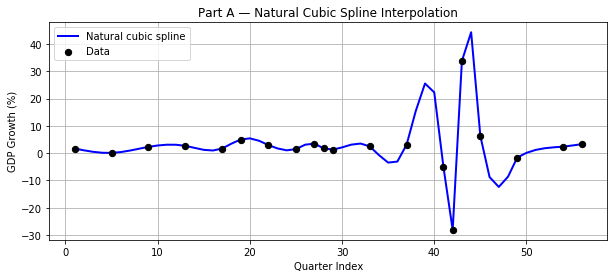

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(X_DATA, Y_DATA, color='black', s=40, zorder=5, label='Data')
ax.plot(X_FULL, Y_spline, color='blue', lw=2, label='Natural cubic spline')
ax.set_title('Part A — Natural Cubic Spline Interpolation')
ax.set_xlabel('Quarter Index')
ax.set_ylabel('GDP Growth (%)')
ax.legend()
ax.grid(True)
plt.show()

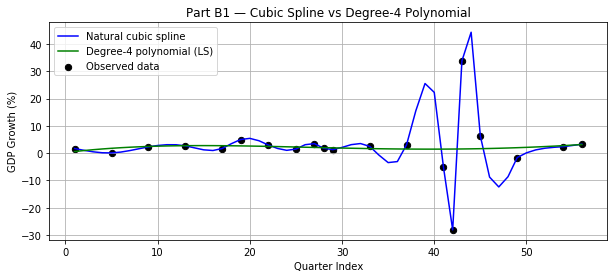

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(X_DATA, Y_DATA, color='black', s=40, label='Observed data')
ax.plot(X_FULL, Y_spline,     color='blue',label='Natural cubic spline')
ax.plot(X_FULL, Y_poly4_full, color='green',label='Degree-4 polynomial (LS)')
ax.set_title('Part B1 — Cubic Spline vs Degree-4 Polynomial')
ax.set_xlabel('Quarter Index')
ax.set_ylabel('GDP Growth (%)')
ax.legend()
ax.grid(True)
plt.show()

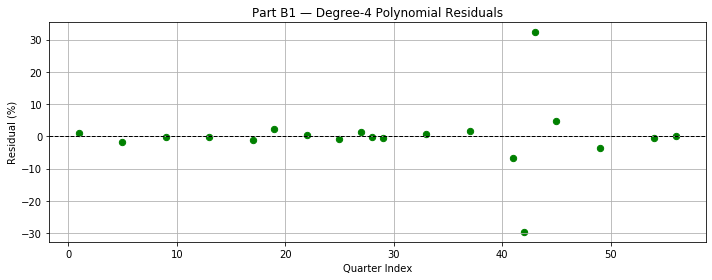

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(X_DATA, resid_poly, color='green', s=40)
ax.axhline(0, color='black', lw=1, ls='--')
ax.set_title('Part B1 — Degree-4 Polynomial Residuals')
ax.set_xlabel('Quarter Index')
ax.set_ylabel('Residual (%)')
ax.grid(True)
plt.tight_layout()
plt.show()

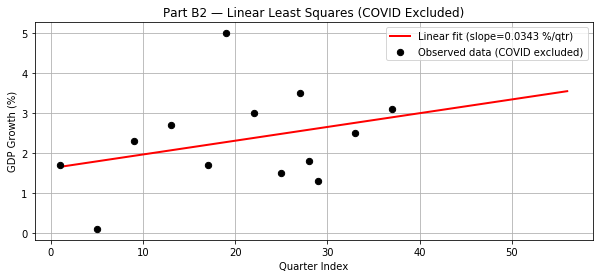

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(x_nc, y_nc, color='black', s=40, zorder=5, label='Observed data (COVID excluded)')
ax.plot(X_FULL, Y_lin_full, color='red', lw=2, label=f'Linear fit (slope={slope:.4f} %/qtr)')
ax.set_title('Part B2 — Linear Least Squares (COVID Excluded)')
ax.set_xlabel('Quarter Index')
ax.set_ylabel('GDP Growth (%)')
ax.legend()
ax.grid(True)
plt.show()

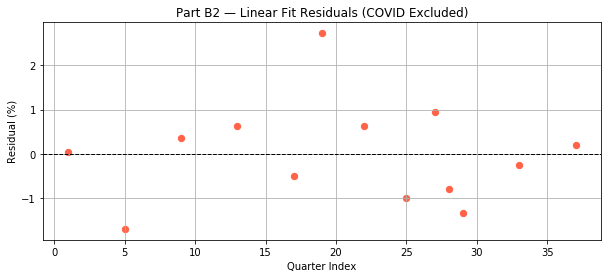

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(x_nc, resid_lin, color='tomato', s=40)
ax.axhline(0, color='black', lw=1, ls='--')
ax.set_title('Part B2 — Linear Fit Residuals (COVID Excluded)')
ax.set_xlabel('Quarter Index')
ax.set_ylabel('Residual (%)')
ax.grid(True)
plt.show()